In [158]:
import kagglehub
from pathlib import Path
import math
import calendar
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy import stats
from scipy.stats import pointbiserialr, f_oneway, chi2_contingency
from statsmodels.stats.multitest import multipletests
from sklearn import metrics
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNet

In [2]:
dataset_handle = "nelgiriyewithana/global-weather-repository"
data_folder = Path("Data-main")

kagglehub.dataset_download(
    dataset_handle,
    output_dir=data_folder,
    force_download=True
)

100%|██████████| 12.0M/12.0M [00:01<00:00, 7.53MB/s]

Extracting files...


WindowsPath('Data-main')

In [3]:
csv_path = list(data_folder.rglob("*.csv"))[0]
df = pd.read_csv(csv_path)
display(df.head())
print(df.shape)
print(df.columns)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


(151827, 41)
Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')


In [4]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

Series([], dtype: int64)


In [15]:
sum(df[df["country"] == "United Kingdom"].location_name != "London")

0

In [180]:
london_df = df[df["country"] == "United Kingdom"].copy()
london_df["last_updated"] = pd.to_datetime(london_df["last_updated"])
london_df.set_index("last_updated", inplace=True)
london_df.sort_index(ascending = True, inplace=True)

display(london_df)
print(london_df.shape)
print(len(np.unique(london_df.index.date)))

,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 09:45:00,United Kingdom,London,51.5200,-0.1100,Europe/London,1715849100,14.0,57.2,Partly cloudy,2.5,...,16.9,19.8,2,2,05:07 AM,08:48 PM,01:02 PM,02:57 AM,Waxing Gibbous,55
2024-05-16 15:15:00,United Kingdom,London,51.5200,-0.1100,Europe/London,1715868900,15.0,59.0,Partly cloudy,6.9,...,2.3,2.7,1,1,05:07 AM,08:48 PM,01:02 PM,02:57 AM,Waxing Gibbous,55
2024-05-17 17:15:00,United Kingdom,London,51.5200,-0.1100,Europe/London,1715962500,21.0,69.8,Sunny,3.8,...,2.5,2.9,1,1,05:05 AM,08:49 PM,02:12 PM,03:09 AM,Waxing Gibbous,64
2024-05-18 15:30:00,United Kingdom,London,51.5200,-0.1100,Europe/London,1716042600,18.0,64.4,Partly cloudy,6.9,...,3.3,3.7,1,1,05:04 AM,08:51 PM,03:22 PM,03:19 AM,Waxing Gibbous,73
2024-05-19 15:15:00,United Kingdom,London,51.5200,-0.1100,Europe/London,1716128100,22.0,71.6,Partly cloudy,9.4,...,6.8,8.0,1,1,05:02 AM,08:52 PM,04:32 PM,03:28 AM,Waxing Gibbous,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-03 07:00:00,United Kingdom,London,51.5171,-0.1062,Europe/London,1783058400,13.1,55.6,Sunny,4.5,...,5.8,9.5,1,1,04:49 AM,09:20 PM,11:18 PM,08:27 AM,Waning Gibbous,92
2026-07-04 06:45:00,United Kingdom,London,51.5171,-0.1062,Europe/London,1783143900,15.4,59.7,Partly cloudy,7.4,...,4.0,5.4,1,1,04:49 AM,09:19 PM,11:30 PM,09:39 AM,Waning Gibbous,86
2026-07-05 06:45:00,United Kingdom,London,51.5171,-0.1062,Europe/London,1783230300,17.4,63.3,Overcast,8.3,...,3.5,5.4,1,1,04:50 AM,09:19 PM,11:40 PM,10:49 AM,Waning Gibbous,78


(778, 40)
777


In [181]:
features_to_remove = ['country', 'location_name', 'latitude', 'longitude', 'timezone',
                     'last_updated_epoch',
                     'temperature_fahrenheit',
                     'condition_text',
                     'wind_mph','wind_direction',
                     'pressure_in', 'precip_in',
                     'feels_like_celsius','feels_like_fahrenheit',
                     'visibility_miles',
                     'gust_mph',
                     'air_quality_us-epa-index', 'air_quality_gb-defra-index', 
                     'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

london_df.drop(columns = features_to_remove, inplace=True)

# Convert sunrise and sunset from string to time of day
for phase in ["sunrise", "sunset"]:

    phase_time = pd.to_datetime(
        london_df[phase],
        format="%I:%M %p",
        errors="coerce"
        )
    
    london_df[phase] = phase_time.dt.hour + phase_time.dt.minute / 60


In [182]:
def create_time_series(df):
    try: 
        date = df.index
        day_of_year = date.dayofyear
        annual_progress = (day_of_year - 1) / np.where(date.is_leap_year, 366, 365)
        day_angle = 2 * np.pi * annual_progress
        
        time_of_day = (
            date.hour
            + date.minute / 60
            + date.second / 3600)
        daily_progress = time_of_day / 24
        time_angle = 2 * np.pi * daily_progress

        df = df.assign(
            day_sin=np.sin(day_angle),
            day_cos=np.cos(day_angle),
            time_sin=np.sin(time_angle),
            time_cos=np.cos(time_angle),
            day_of_year = day_of_year,
            time_of_day = time_of_day,
            )

        return df
    except AttributeError:
        print("AttributeError: index not in datetime")

def decompose_wind(df):
    wind_rad = np.radians(df["wind_degree"])

    # Meteorological convention:
    # wind_degree = direction wind comes FROM
    df["wind_x"] = -df["wind_kph"] * np.sin(wind_rad)  # east-west component
    df["wind_y"] = -df["wind_kph"] * np.cos(wind_rad)  # north-south component

    df.drop(columns = ["wind_degree", "wind_kph"], inplace=True)
    return df

london_df = decompose_wind(create_time_series(london_df))
display(london_df)

,temperature_celsius,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,...,sunrise,sunset,day_sin,day_cos,time_sin,time_cos,day_of_year,time_of_day,wind_x,wind_y
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 09:45:00,14.0,1005.0,0.20,88,50,10.0,3.0,6.2,383.9,0.5,...,5.116667,20.800000,0.722117,-0.691771,0.555570,-0.831470,137,9.75,-3.464102,2.000000
2024-05-16 15:15:00,15.0,1005.0,0.01,77,50,10.0,3.0,18.4,207.0,68.0,...,5.116667,20.800000,0.722117,-0.691771,-0.751840,-0.659346,137,15.25,3.830626,10.524557
2024-05-17 17:15:00,21.0,1010.0,0.40,43,0,10.0,4.0,13.3,207.0,75.1,...,5.083333,20.816667,0.710135,-0.704066,-0.980785,-0.195090,138,17.25,-6.007327,-1.059254
2024-05-18 15:30:00,18.0,1013.0,0.19,68,50,10.0,4.0,14.2,203.6,86.6,...,5.066667,20.850000,0.697944,-0.716152,-0.793353,-0.608761,139,15.50,-9.699485,-5.600000
2024-05-19 15:15:00,22.0,1014.0,0.00,46,50,10.0,6.0,21.1,193.6,120.2,...,5.033333,20.866667,0.685548,-0.728028,-0.751840,-0.659346,140,15.25,-9.706093,-11.567271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-03 07:00:00,13.1,1029.0,0.00,77,0,10.0,0.6,9.0,131.0,43.0,...,4.816667,21.333333,-0.008607,-0.999963,0.965926,-0.258819,184,7.00,4.723625,-5.433909
2026-07-04 06:45:00,15.4,1027.0,0.00,88,75,10.0,0.2,16.4,115.0,37.0,...,4.816667,21.316667,-0.025818,-0.999667,0.980785,-0.195090,185,6.75,11.784190,1.656160
2026-07-05 06:45:00,17.4,1025.0,0.00,83,100,10.0,0.2,17.9,94.0,29.0,...,4.833333,21.316667,-0.043022,-0.999074,0.980785,-0.195090,186,6.75,13.136255,-2.080578


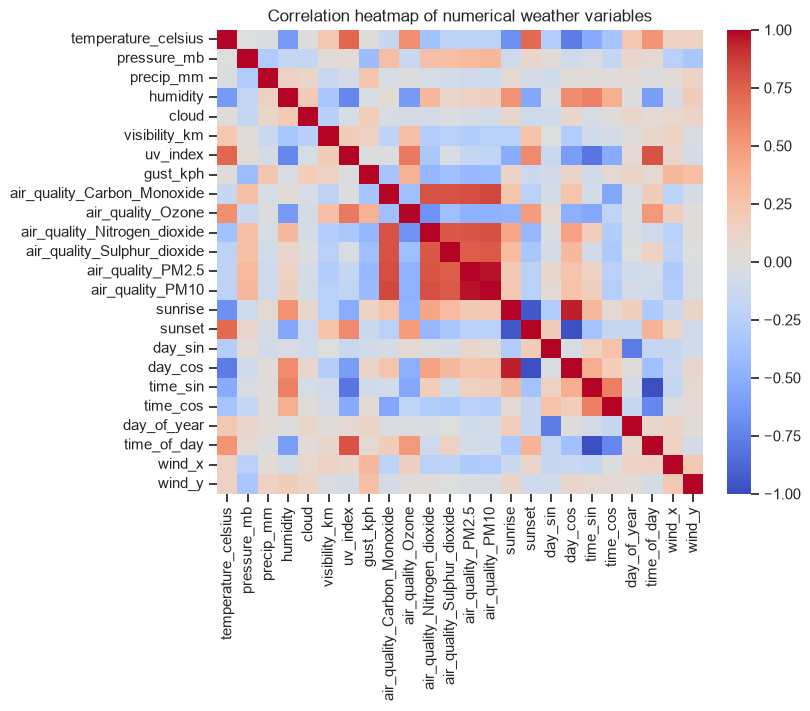

In [184]:
corr = london_df.corr()

fig, ax = plt.subplots(figsize=(8, 7), layout="constrained")

sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False
)

ax.set_title("Correlation heatmap of numerical weather variables")
plt.show()

london_df.drop(columns=["gust_kph", "air_quality_PM10"], inplace=True)

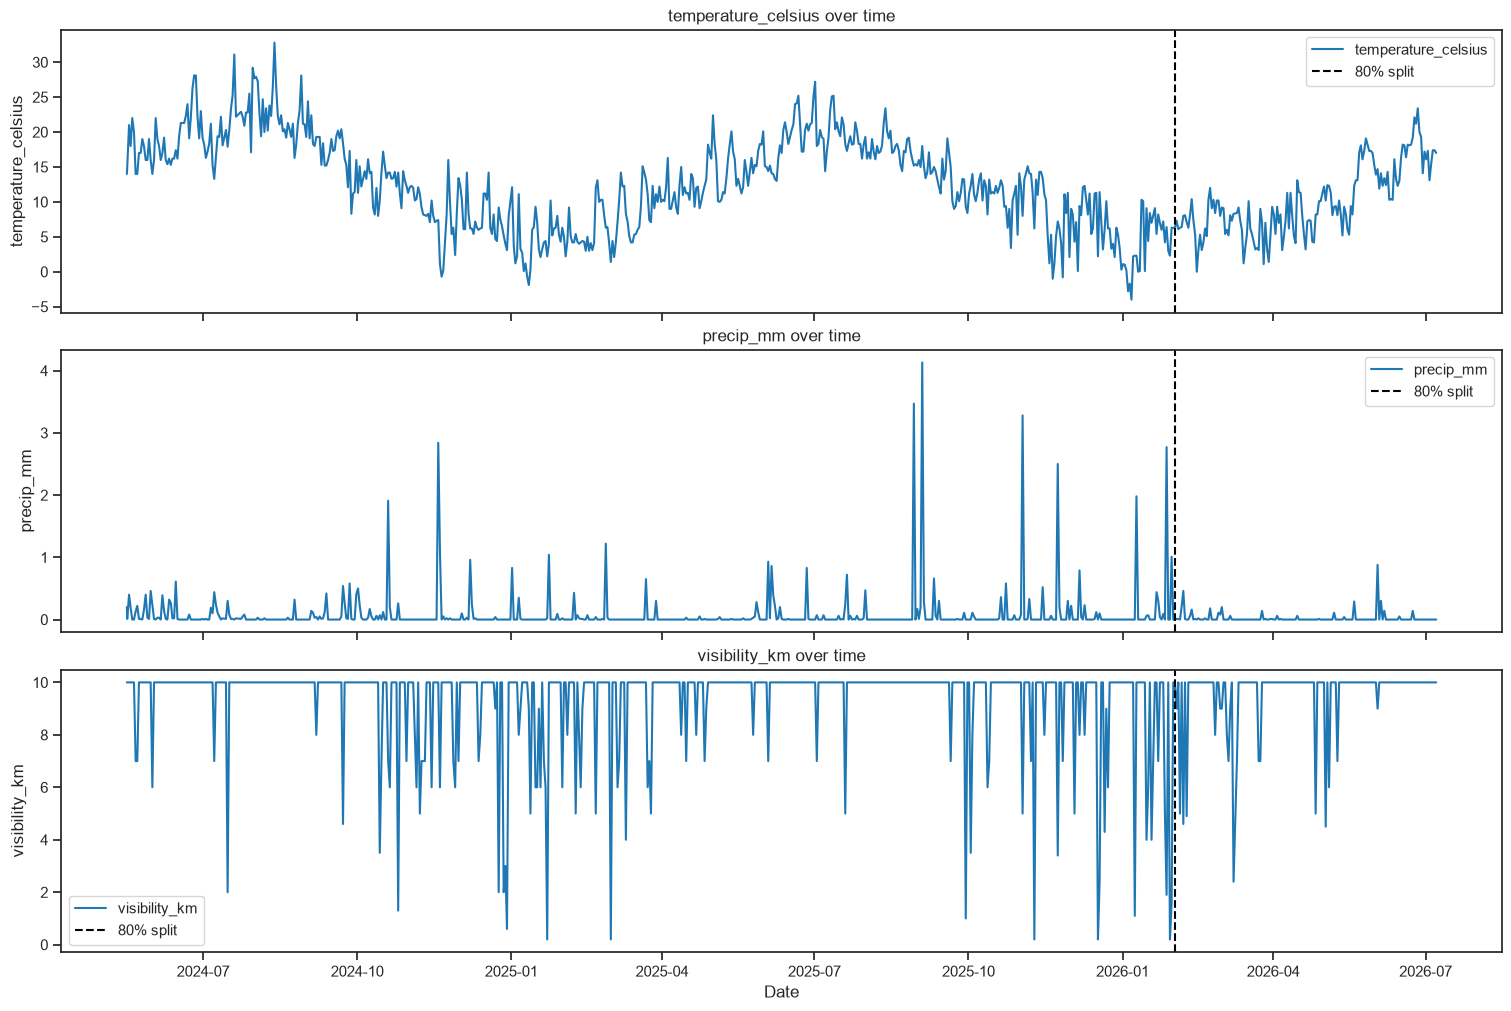

In [185]:
features = ["temperature_celsius", "precip_mm", "visibility_km"]

split = int(london_df.shape[0] * 0.8)
split_date = london_df.index[split]

train_df = london_df.iloc[:split]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 10),
    layout="constrained",
    sharex=True
)

for ax, feature in zip(axes, features):

    ax.plot(
        london_df.index,
        london_df[feature],
        label=feature
    )

    ax.axvline(
        split_date,
        color="black",
        linestyle="--",
        label="80% split"
    )

    ax.set_ylabel(feature)
    ax.set_title(f"{feature} over time")
    ax.legend()

axes[-1].set_xlabel("Date")

plt.show()

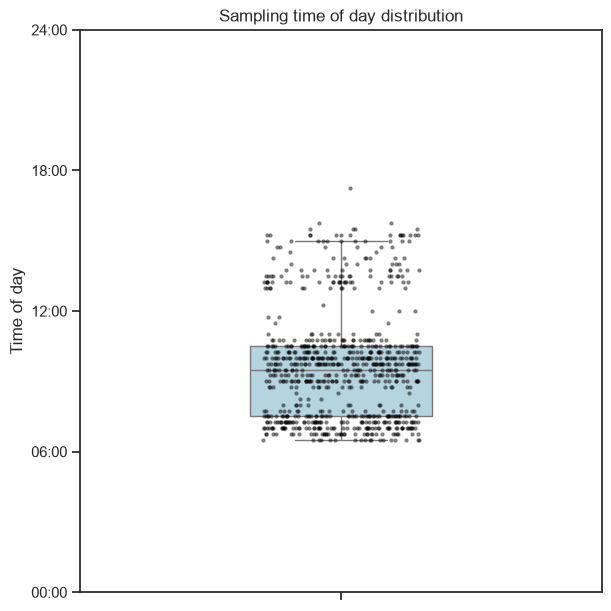

In [186]:
time = london_df.index

time_of_day = ( 
            time.hour
            + time.minute / 60 
            + time.second / 3600)

fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")

sns.boxplot(
    y=time_of_day,
    ax=ax,
    color="lightblue",
    width=0.35,
    showfliers=False
)

sns.stripplot(
    y=time_of_day,
    ax=ax,
    color="black",
    size=3,
    alpha=0.5,
    jitter=0.15
)

ax.set_ylabel("Time of day")
ax.set_title("Sampling time of day distribution")

ax.set_yticks([0, 6, 12, 18, 24])
ax.set_yticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

plt.show()

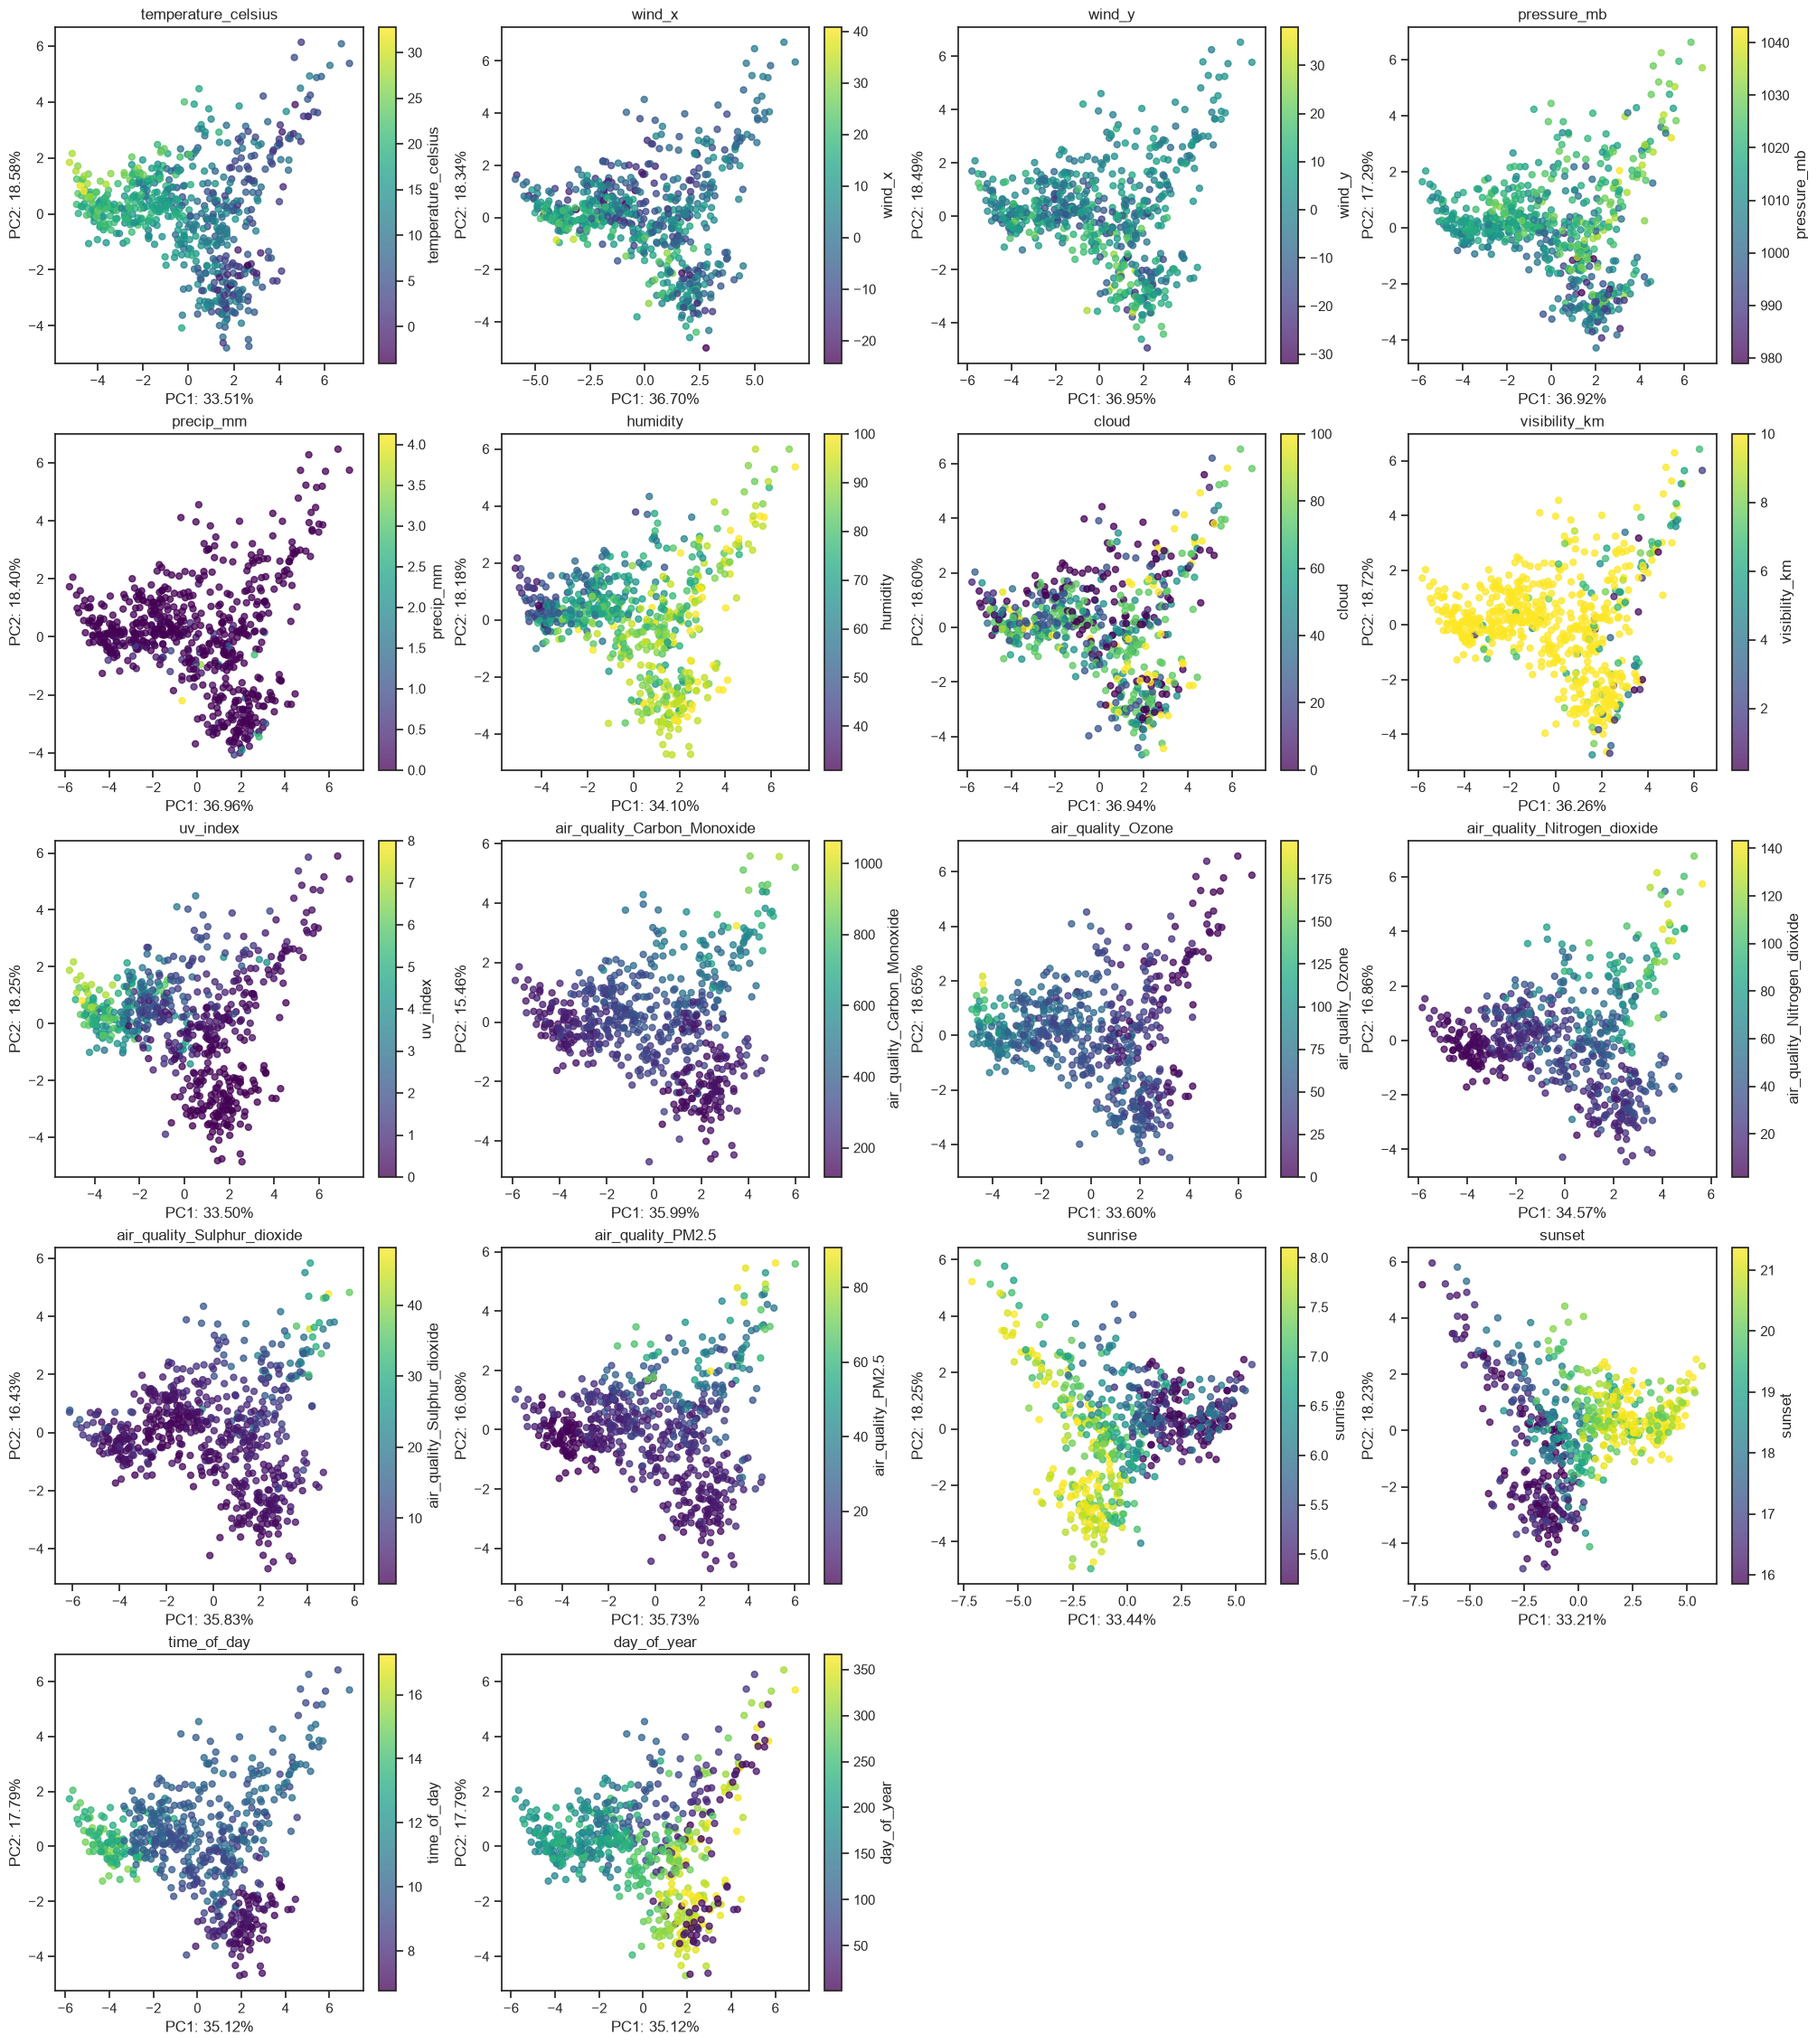

In [188]:
split = int(london_df.shape[0]*0.8)

train_df = london_df.iloc[:split,].copy()
test_df = london_df.iloc[split:,].copy()

feature_list = ['temperature_celsius', 'wind_x', 'wind_y', 'pressure_mb',
       'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'sunrise', 'sunset','time_of_day','day_of_year']

ncols = 4
nrows = math.ceil(len(feature_list) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4.5 * nrows),
    layout="constrained"
)

axes = axes.ravel()

for ax, feature in zip(axes, feature_list):

    # Drop the feature being used as colour, plus time variables if present
    X_train = train_df.drop(columns=set([feature, "time_of_day", "day_of_year"]))
    y_train = train_df[feature].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    pca = PCA(n_components=5)
    pca_data = pca.fit_transform(X_train_scaled)

    pvars = pca.explained_variance_ratio_[:2] * 100

    scatter = ax.scatter(
        pca_data[:, 0],
        pca_data[:, 1],
        c=y_train,
        cmap="viridis",
        alpha=0.75,
        s=25
    )

    ax.set_title(feature)
    ax.set_xlabel(f"PC1: {pvars[0]:.2f}%")
    ax.set_ylabel(f"PC2: {pvars[1]:.2f}%")

    fig.colorbar(scatter, ax=ax, label=feature)

# Hide unused axes if grid has empty spaces
for ax in axes[len(feature_list):]:
    ax.set_visible(False)

plt.show()


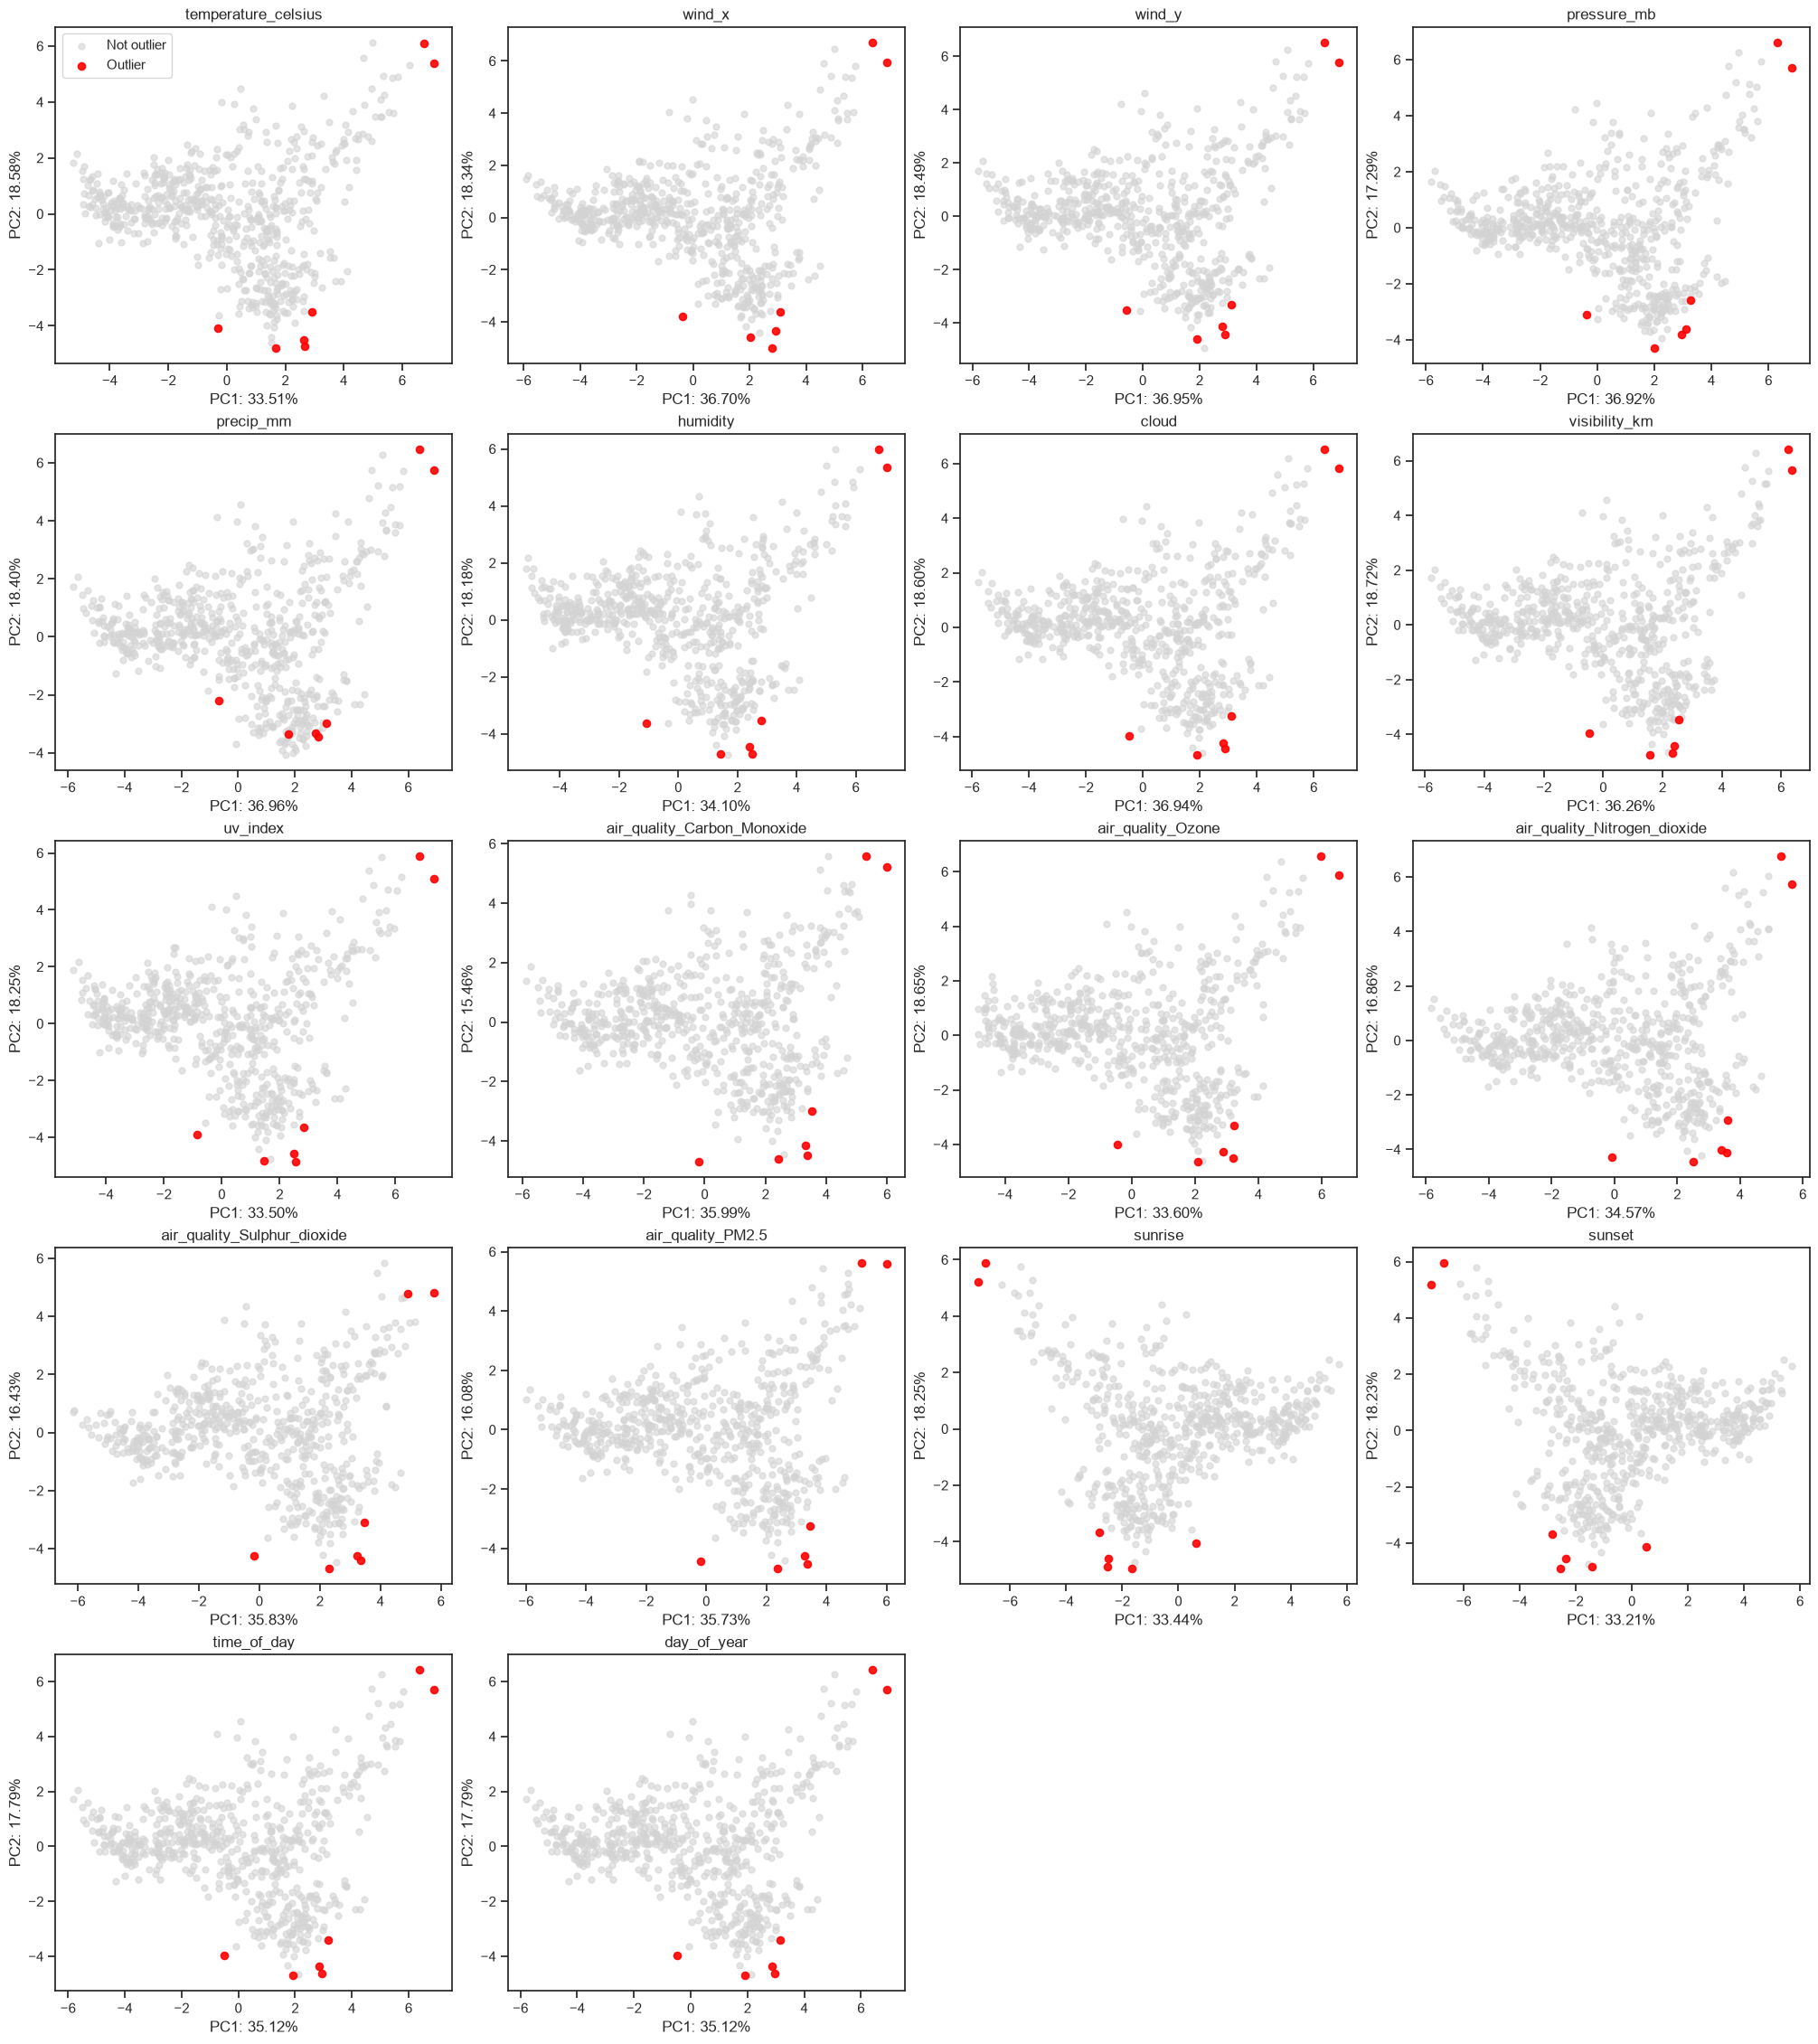

In [189]:
def find_outliers(train_df, alpha=0.05, n_components=5):

    X_train = train_df.drop(columns=["time_of_day", "day_of_year"])

    X_train_scaled = StandardScaler().fit_transform(X_train)

    pca_data = PCA(n_components=n_components).fit_transform(X_train_scaled)

    n = pca_data.shape[0]
    p = pca_data.shape[1]

    cov_matrix = np.cov(pca_data, rowvar=False)
    inv_cov = np.linalg.pinv(cov_matrix)

    T2 = np.array([
        pca_data[i, :] @ inv_cov @ pca_data[i, :].T
        for i in range(n)
    ])

    p_values = 1 - stats.chi2.cdf(T2, df=p)

    outlier, p_values_bh, _, _ = multipletests(
        p_values,
        alpha=alpha,
        method="fdr_bh"
    )

    return outlier

ncols = 4
nrows = math.ceil(len(feature_list) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4.5 * nrows),
    layout="constrained"
)

axes = axes.ravel()
outlier = find_outliers(train_df)

for ax, feature in zip(axes, feature_list):

    # Drop the feature being used as colour, plus time variables if present
    X_train = train_df.drop(columns=set([feature, "time_of_day", "day_of_year"]))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    pca = PCA(n_components=5)
    pca_data = pca.fit_transform(X_train_scaled)

    pvars = pca.explained_variance_ratio_[:2] * 100

    # Non-outliers: grey
    ax.scatter(
        pca_data[~outlier, 0],
        pca_data[~outlier, 1],
        color="lightgrey",
        alpha=0.6,
        s=25,
        label="Not outlier"
    )

    # Outliers: red
    ax.scatter(
        pca_data[outlier, 0],
        pca_data[outlier, 1],
        color="red",
        alpha=0.9,
        s=35,
        label="Outlier"
    )

    ax.set_title(feature)
    ax.set_xlabel(f"PC1: {pvars[0]:.2f}%")
    ax.set_ylabel(f"PC2: {pvars[1]:.2f}%")
    if ax == axes[0]:
        ax.legend()

# Hide unused axes if grid has empty spaces
for ax in axes[len(feature_list):]:
    ax.set_visible(False)

plt.show()

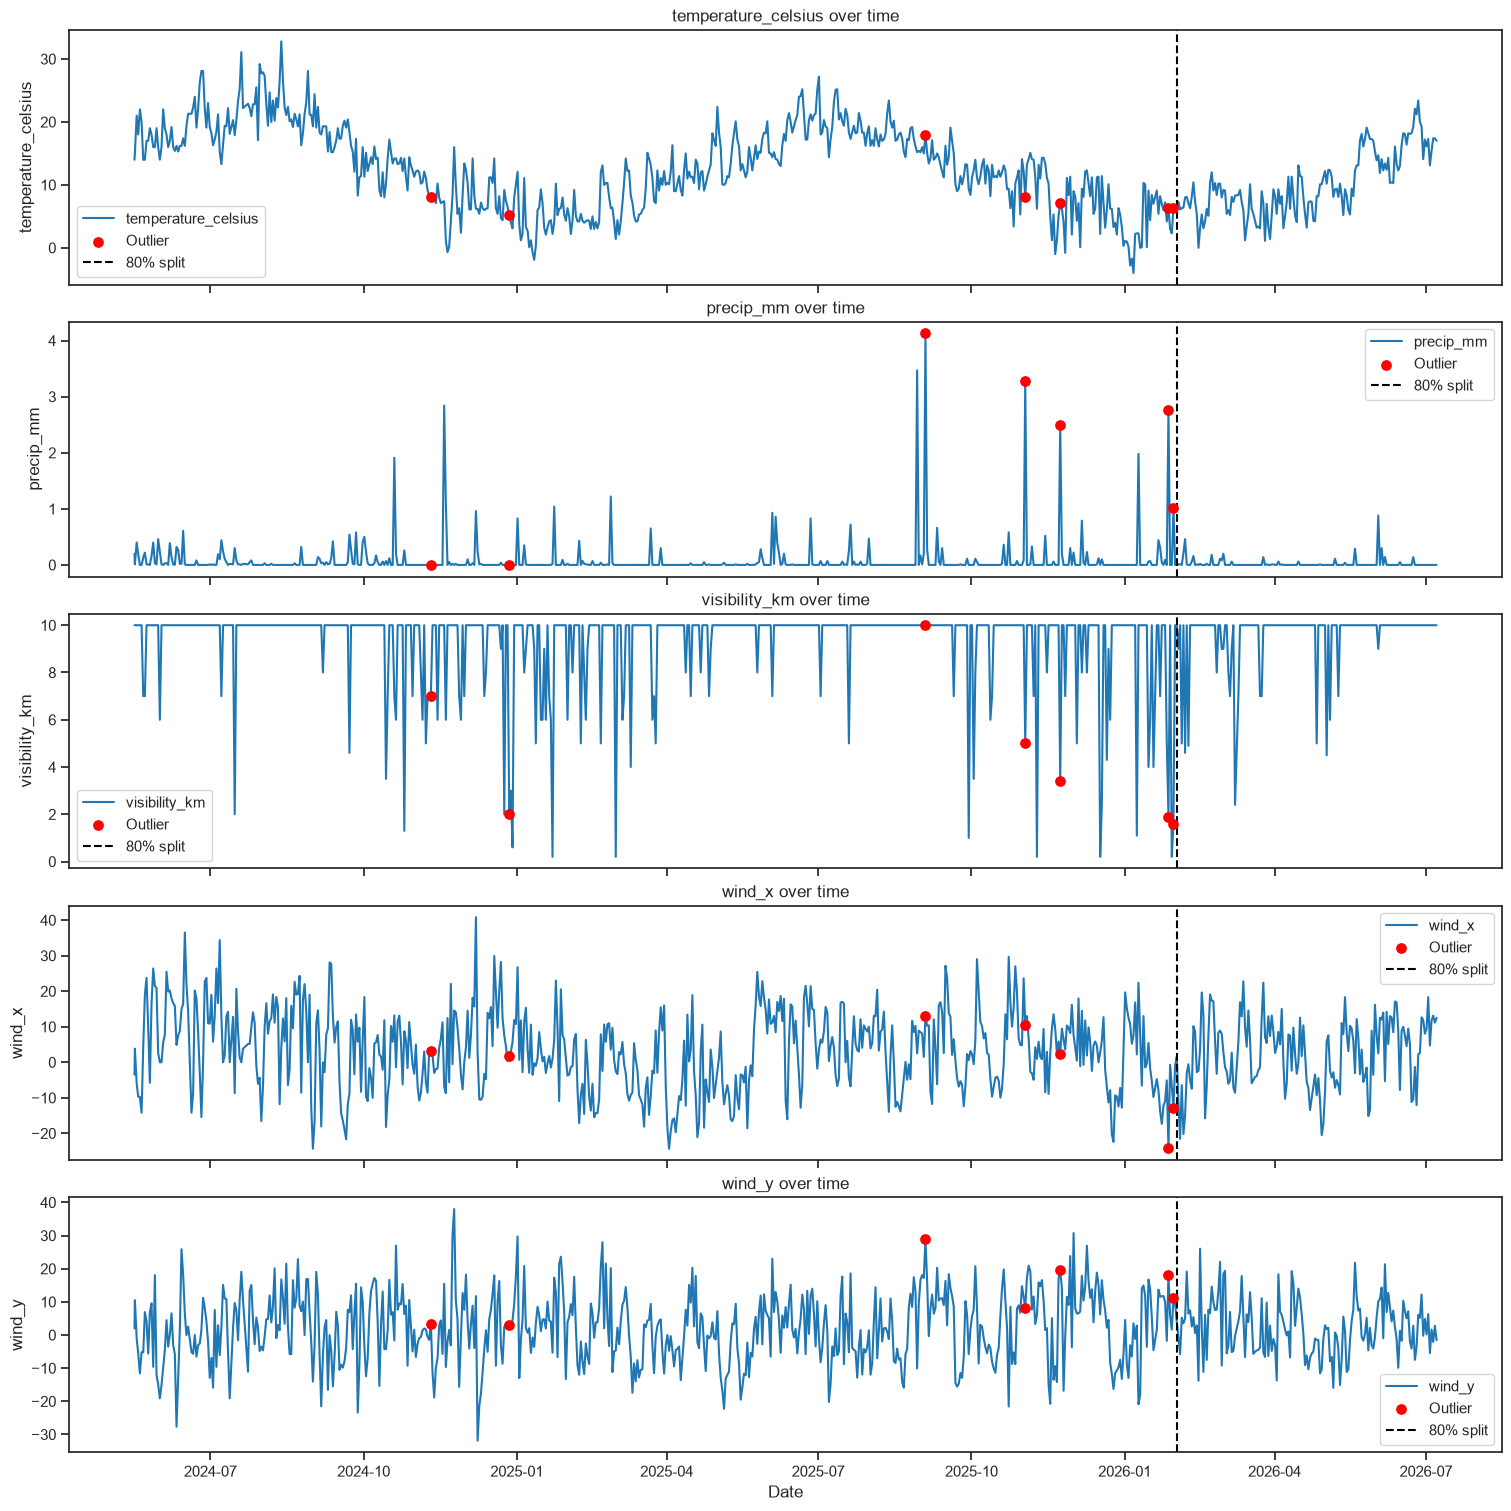

In [191]:
features = ["temperature_celsius", "precip_mm", "visibility_km", "wind_x", "wind_y", "uv_index"]

split = int(london_df.shape[0] * 0.8)
split_date = london_df.index[split]

train_df = london_df.iloc[:split]

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(15, 15),
    layout="constrained",
    sharex=True
)

for ax, feature in zip(axes, features):

    ax.plot(
        london_df.index,
        london_df[feature],
        label=feature
    )

    ax.scatter(
        train_df.index[outlier],
        train_df.loc[outlier, feature],
        color="red",
        s=45,
        zorder=3,
        label="Outlier"
    )

    ax.axvline(
        split_date,
        color="black",
        linestyle="--",
        label="80% split"
    )

    ax.set_ylabel(feature)
    ax.set_title(f"{feature} over time")
    ax.legend()

axes[-1].set_xlabel("Date")

plt.show()